In [438]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Functions

In [439]:

def get_pv_mesh_from_atlas(bg_atlas, structure_name):
    """
    Get a PyVista mesh from the BrainGlobe Atlas for a given structure name.
    Args:
        bg_atlas (BrainGlobeAtlas): The BrainGlobe Atlas object.
        structure_name (str): The name of the structure to retrieve.
    Returns:
        pv.PolyData: The PyVista mesh of the specified structure.
    """
    print(f"Selected structure {bg_atlas.structures[structure_name]['name']}")
    pv_brain_mesh   = pv.read(bg_atlas.structures[structure_name]['mesh_filename']) 

    return pv_brain_mesh


def add_brain_mesh(pv_brain_mesh, *,
                        plotter=None,
                        window_size= [800, 800],
                        notebook=True,
                        off_screen=False,
                        **kwargs):
    """
    Plot the PyVista mesh of a specified structure.
    Args:
        pv_brain_mesh (pv.PolyData): The PyVista mesh of the structure.
        plotter (pv.Plotter, optional): A PyVista plotter instance. If None, a new one will be created.
        plotter_args (dict, optional): Additional arguments for the plotter.
        **kwargs: Additional keyword arguments for the mesh rendering.
    Returns:
        pv.Plotter: The PyVista plotter with the mesh added.
    """
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size, 
                             off_screen=off_screen)
    default_kwargs = {
        'color': 'lightgrey',  # Default color for the mesh
        'opacity': 0.2,  # Default opacity for the mesh
        'label' : "Brain Region",  # label for the legend
    }
    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value

    plotter.add_mesh(pv_brain_mesh, **kwargs)
    return plotter

def add_doppler_vol(doppler3D_vol,*, 
                    plotter = None,
                    notebook = True,
                    window_size = [700,700],
                    off_screen=False,
                    **kwargs):
    """
    Plot the ultrasound volume using PyVista.
    Args:
        doppler3D_vol (pv.ImageData): The ultrasound volume data.
        cmap (str): Colormap to use for the volume rendering.
        opacity (str or tuple): Opacity function for the volume rendering.
        clim (list): Color limits for the scalars.
    """
    if plotter is None:
    	plotter = pv.Plotter(window_size=window_size, notebook=notebook,
                             off_screen=off_screen)
    
    default_kwargs = {
        'scalars': 'BMODE',  # Assuming 'BMODE' is a scalar field in doppler3D_vol
        'cmap': 'hot',
        'opacity': 'sigmoid',
        'mapper': 'smart',
        'show_scalar_bar': True,
        'scalar_bar_args': {
            'title': 'Doppler (dB)',
            "title_font_size": 16,
            "label_font_size": 12,
        },
    }
    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value
    
    vol=plotter.add_volume(doppler3D_vol, **kwargs)
    vol.prop.interpolation_type = 'linear'
    plotter.show_axes()
    plotter.show_grid()
    return plotter

def add_transducer_mesh(TX_mesh, *,
                        plotter=None,
                        window_size=[800, 800],
                        notebook=True,
                        off_screen=False,
                        **kwargs):
    
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size,
                             off_screen=off_screen)

    default_kwargs = {
        'scalars': 'Apodization',  # Assuming 'Apodization' is a scalar field in TX_mesh
        'cmap': 'cool',
        'clim': [0, 1],
        'opacity': 1.0,
        'show_edges': True,
        'show_scalar_bar': True,
        'scalar_bar_args': {
            'title': 'Apodization',
            "title_font_size": 16,
            "label_font_size": 12,
            'vertical': True,
            'position_x': 0.85,
            'position_y': 0.5,
            "height": 0.3,
        },
        'label' : "Transducer",  # label for the legend
        'color' : "purple", # color of the mesh
    }

    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value



    plotter.add_mesh(TX_mesh,   # Convert to mm for visualization
            **kwargs
        )
    return plotter

def add_pressure_vol(pressure_vol,*,
                    plotter=None,
                    window_size=[800, 800],
                    notebook=True,
                    plot_focal_spot = True,
                    off_screen=False,
                    **kwargs):
    
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size,
                             off_screen=off_screen)

    # 3) Add the pressure volume
    if plot_focal_spot:
        
        default_kwargs = {
            'opacity': 1,
            'name' : "PressureIso",
            'show_scalar_bar': False,
            'label': "Focal Spot",  # label for the legend
            'color' : "r", # color of the mesh
        }
        for key, value in default_kwargs.items():
            if key not in kwargs:
                kwargs[key] = value
                
        # pick a threshold, e.g. halfway to the max
        threshold = 0.7 * pressure_vol["Pressure"].max()
        iso_mesh = pressure_vol.contour([threshold], scalars="Pressure")  # Create isosurface at threshold# add that instead of (or in addition to) the volume
        plotter.add_mesh(iso_mesh, **kwargs)    

    else:
        n_contours = 10
        min_val = 0
        max_val = pressure_vol["Pressure"].max()
        levels = np.linspace(min_val, max_val, n_contours)
        iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")  # Create isosurface at threshold
        default_kwargs = {
            'scalars': "Pressure",  # use the scalar to color surfaces
            'opacity': 'linear',
            'cmap' : "jet",
            'show_scalar_bar': True,
            'scalar_bar_args': {
                'title': 'Pressure (u.a.)',
                "title_font_size": 16,
                "label_font_size": 12,
                'vertical': True,
                'position_x': 0.85,
                'position_y': 0.2,
                "height": 0.3,
            },
            'label': "Pressure PII",  # label for the legend
            'color' : "r", # color of the mesh
        }
        for key, value in default_kwargs.items():
            if key not in kwargs:
                kwargs[key] = value

        plotter.add_mesh(iso_mesh, **kwargs)

    return plotter

In [440]:
def compute_2D_image_mesh(Bmode2D_dB, T) :
    """
    Compute a 2D image mesh from a B-mode ultrasound image and a transformation matrix.
    Args:
        Bmode2D_dB (np.ndarray): 2D array of B-mode ultrasound data in dB.
        T (np.ndarray): 4x4 transformation matrix to convert voxel coordinates to world coordinates.
    Returns:
        pv.StructuredGrid: A structured grid representing the 2D image in world coordinates.
    """
    H, W = Bmode2D_dB.shape

    # Create grid indices
    j_grid, i_grid = np.meshgrid(np.arange(W), np.arange(H))

    # Construct homogeneous voxel coordinates [j, 0, i, 1]
    points_voxel = np.stack([j_grid, np.zeros_like(j_grid), i_grid, np.ones_like(j_grid)], axis=-1)
    points_voxel_flat = points_voxel.reshape(-1, 4).T  # Shape (4, H*W)

    # Transform to world coordinates
    points_world_flat = T @ points_voxel_flat  # Shape (4, H*W)

    # Create structured grid
    xx = points_world_flat[0].reshape(H, W)
    yy = points_world_flat[1].reshape(H, W)
    zz = points_world_flat[2].reshape(H, W)
    grid = pv.StructuredGrid(xx, yy, zz)
    grid["doppler"] = Bmode2D_dB.ravel(order="F")  # Add scalar data # FORTRAN ORDER IMPORTANT
    return grid

def add_2D_image(image_grid,*, 
                plotter = None,
                notebook = True,
                window_size = [700,700],
                off_screen=False,
                **kwargs):
    """
    Plot the ultrasound volume using PyVista.
    Args:
        doppler3D_vol (pv.ImageData): The ultrasound volume data.
        cmap (str): Colormap to use for the volume rendering.
        opacity (str or tuple): Opacity function for the volume rendering.
        clim (list): Color limits for the scalars.
    """
    if plotter is None:
        plotter = pv.Plotter(window_size=window_size, notebook=notebook,
                                off_screen=off_screen)

    default_kwargs = {
        'show_edges':False,
        'cmap':'gray',
        'opacity':1.0,
        'name':'2D doppler',  # Name for the volume
        'show_scalar_bar':False,
        'show_scalar_bar': True,
        'scalar_bar_args': {
            'title': '2D Doppler (dB)',
            "title_font_size": 16,
            "label_font_size": 12,
            'vertical': True,
            'position_x': 0.1,
            'position_y': 0.2,
            "height": 0.3,
        },
        'label' : "2D Doppler",  # label for the legend	
    }
    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value

    vol=plotter.add_mesh(image_grid, **kwargs)
    plotter.show_axes()
    plotter.show_grid()
    return plotter

# 2. Import data

In [441]:
import h5py

gps_file = h5py.File(r"C:\Users\INSERM\Documents\Esteban\PySonoGen\src\pysonogen\datatype\Angio_angio3D.source.bps", "r")
file_scan_3D = h5py.File(r"C:\Users\INSERM\Documents\Esteban\PySonoGen\src\pysonogen\datatype\Angio_angio3D.source.scan", "r")
file_scan_2D = h5py.File(r"C:\Users\INSERM\Documents\Esteban\PySonoGen\src/pysonogen/datatype/Stim_008_fUS2D.source.scan", "r")

# Let's take the 008 scan. It shouwld be placed at one sagittal plane on the left side of the brain
# 

In [442]:
print("------gpsreg keys------")
print(gps_file.keys())
for key in gps_file.keys():
    print(f"{key}: {gps_file[key].shape} {gps_file[key].dtype}")

print("------scan_3D keys------")
print(file_scan_3D.keys())
for key in file_scan_3D.keys():
    print(f"{key}: {file_scan_3D[key]} ")
    
print("------scan_2D keys------")
print(file_scan_2D.keys())
for key in file_scan_2D.keys():
    print(f"{key}: {file_scan_2D[key]} ")

------gpsreg keys------
<KeysViewHDF5 ['BrainToLab', 'method', 'ref_name', 'score']>
BrainToLab: (4, 4) float64
method: () |S5
ref_name: () |S1
score: (1,) float64
------scan_3D keys------
<KeysViewHDF5 ['Data', 'acqMetaData', 'fileFormatVersion', 'fileID', 'scanMetaData', 'writingVersion']>
Data: <HDF5 dataset "Data": shape (41, 1, 163, 1, 128), type "<f8"> 
acqMetaData: <HDF5 group "/acqMetaData" (9 members)> 
fileFormatVersion: <HDF5 dataset "fileFormatVersion": shape (1, 1), type "<f8"> 
fileID: <HDF5 dataset "fileID": shape (1, 1), type "|O"> 
scanMetaData: <HDF5 group "/scanMetaData" (12 members)> 
writingVersion: <HDF5 dataset "writingVersion": shape (1, 1), type "<f8"> 
------scan_2D keys------
<KeysViewHDF5 ['Data', 'acqMetaData', 'fileFormatVersion', 'fileID', 'scanMetaData', 'writingVersion']>
Data: <HDF5 dataset "Data": shape (10, 92, 1, 128), type "<f8"> 
acqMetaData: <HDF5 group "/acqMetaData" (9 members)> 
fileFormatVersion: <HDF5 dataset "fileFormatVersion": shape (1, 1

In [443]:
scan2D_data = file_scan_2D['Data'][()]
print("Shape of scan2D_data:", scan2D_data.shape)
# The 2D scan data is typically in the shape (time, width, height, depth), where time is the number of frames
scan2D_processed = scan2D_data.mean(axis=0).reshape(scan2D_data.shape[1:])  # Average over the time dimension
print("Shape of scan2D_processed:", scan2D_processed.shape)

Shape of scan2D_data: (10, 92, 1, 128)
Shape of scan2D_processed: (92, 1, 128)


In [444]:
scan3D_data = file_scan_3D['Data'][()]
#If the space between the planes is small enough, we could treat
# each plane as slices and we discard the temporal information,
# we can then compute a 3D matrix with (x,y,z) information.
data3D_processed = scan3D_data.squeeze().transpose([2,0,1])
print("data3D_processed:", data3D_processed.shape)


data3D_processed: (128, 41, 163)


In [445]:
scan3D_metadata = file_scan_3D['acqMetaData']
print("\nscan3D_metadata:")
for key in scan3D_metadata.keys():
    print(f"{key}  : {scan3D_metadata[key]}")

scan2D_metadata = file_scan_2D['acqMetaData']
print("\nscan2D_metadata:")
for key in scan3D_metadata.keys():
    print(f"{key}  : {scan3D_metadata[key]}")


scan3D_metadata:
acquisitionMode  : <HDF5 dataset "acquisitionMode": shape (1, 1), type "|O">
imgDim  : <HDF5 group "/acqMetaData/imgDim" (7 members)>
key7  : <HDF5 dataset "key7": shape (1, 1), type "|O">
probeToLab  : <HDF5 dataset "probeToLab": shape (41, 4, 4), type "<f8">
robotType  : <HDF5 dataset "robotType": shape (1, 1), type "|O">
time  : <HDF5 dataset "time": shape (41, 1), type "<f8">
timeOriginal  : <HDF5 dataset "timeOriginal": shape (41, 1), type "<f8">
voxDim  : <HDF5 group "/acqMetaData/voxDim" (4 members)>
voxelsToProbe  : <HDF5 dataset "voxelsToProbe": shape (4, 4), type "<f8">

scan2D_metadata:
acquisitionMode  : <HDF5 dataset "acquisitionMode": shape (1, 1), type "|O">
imgDim  : <HDF5 group "/acqMetaData/imgDim" (7 members)>
key7  : <HDF5 dataset "key7": shape (1, 1), type "|O">
probeToLab  : <HDF5 dataset "probeToLab": shape (41, 4, 4), type "<f8">
robotType  : <HDF5 dataset "robotType": shape (1, 1), type "|O">
time  : <HDF5 dataset "time": shape (41, 1), type "

# 2. qform : volxel -> Lab

In [446]:
voxelsToProbe3D = scan3D_metadata["voxelsToProbe"][()]
probeToLab3D = scan3D_metadata["probeToLab"][()]

voxelsToProbe2D = scan2D_metadata["voxelsToProbe"][()]
probeToLab2D = scan2D_metadata["probeToLab"][()]

In [447]:
invert_z = np.diag([1, 1, -1, 1])  # Invert z-axis
rescale_m2mm = np.diag([1e3, 1e3, 1e3, 1])  # Rescale from meters to millimeters

In [448]:
voxels2Lab3D = probeToLab3D[0].squeeze() @ voxelsToProbe3D 
qform = invert_z @ voxels2Lab3D 
qform = rescale_m2mm @ qform  # Rescale to mm

print("voxelsToProbe3D: \n", voxelsToProbe3D)
print("probeToLab3D i = 0: \n", probeToLab3D[0])
print("probeToLab3D i = -1: \n", probeToLab3D[-1])
print("qform (mm):\n", qform)

voxelsToProbe3D: 
 [[ 1.10000e-04  0.00000e+00  0.00000e+00 -7.09500e-03]
 [ 0.00000e+00  2.00000e-04  0.00000e+00 -2.00000e-04]
 [ 0.00000e+00  0.00000e+00 -9.85600e-05 -4.90144e-03]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+00]]
probeToLab3D i = 0: 
 [[ 0.        1.        0.       -0.001301]
 [-1.        0.        0.        0.0075  ]
 [ 0.        0.        1.       -0.044198]
 [ 0.        0.        0.        1.      ]]
probeToLab3D i = -1: 
 [[ 0.        1.        0.        0.006699]
 [-1.        0.        0.        0.0075  ]
 [ 0.        0.        1.       -0.044198]
 [ 0.        0.        0.        1.      ]]
qform (mm):
 [[ 0.       0.2      0.      -1.501  ]
 [-0.11     0.       0.      14.595  ]
 [ 0.       0.       0.09856 49.09944]
 [ 0.       0.       0.       1.     ]]


In [449]:
voxels2Lab2D = probeToLab2D @ voxelsToProbe2D 
qform2D = invert_z @ voxels2Lab2D 
qform2D = rescale_m2mm @ qform2D

print("voxelsToProbe2D: \n", voxelsToProbe2D)
print("probeToLab2D i = 0: \n", probeToLab2D)
print("qform2D (mm):\n", qform2D)

voxelsToProbe2D: 
 [[ 1.1000e-04  0.0000e+00  0.0000e+00 -7.0950e-03]
 [ 0.0000e+00  4.0000e-04  0.0000e+00 -4.0000e-04]
 [ 0.0000e+00  0.0000e+00 -9.8560e-05 -9.0144e-04]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  1.0000e+00]]
probeToLab2D i = 0: 
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
qform2D (mm):
 [[ 0.11     0.       0.      -7.095  ]
 [ 0.       0.4      0.      -0.4    ]
 [ 0.       0.       0.09856  0.90144]
 [ 0.       0.       0.       1.     ]]


In [450]:
labToProbe3D = np.linalg.inv(probeToLab3D[0])
labToProbe2D = np.linalg.inv(probeToLab2D)

rescale_translation_m2mm = np.ones_like(labToProbe3D)
rescale_translation_m2mm[:3, 3] = 1e3  # Only scale translation part

lab2Probe3D = rescale_translation_m2mm * ( labToProbe3D )
lab2Probe2D = rescale_translation_m2mm * ( labToProbe2D )
print("lab2Probe 2D (mm):\n", lab2Probe2D)
print("lab2Probe 3D (mm):\n", lab2Probe3D)

lab2Probe 2D (mm):
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
lab2Probe 3D (mm):
 [[-0.    -1.    -0.     7.5  ]
 [ 1.     0.     0.     1.301]
 [ 0.     0.     1.    44.198]
 [ 0.     0.     0.     1.   ]]


In [451]:
probeToLab3D[0]

array([[ 0.      ,  1.      ,  0.      , -0.001301],
       [-1.      ,  0.      ,  0.      ,  0.0075  ],
       [ 0.      ,  0.      ,  1.      , -0.044198],
       [ 0.      ,  0.      ,  0.      ,  1.      ]])

In [452]:
np.linalg.inv(probeToLab3D[0])

array([[-0.      , -1.      , -0.      ,  0.0075  ],
       [ 1.      ,  0.      ,  0.      ,  0.001301],
       [ 0.      ,  0.      ,  1.      ,  0.044198],
       [ 0.      ,  0.      ,  0.      ,  1.      ]])

In [453]:
# translate_lab2probe3D = (rescale_m2mm @ invert_z @ voxelsToProbe3D)[:3, 3] - qform[:3, 3] 
# translate_lab2probe2D = (rescale_m2mm @ invert_z @ voxelsToProbe2D)[:3, 3] - qform2D[:3, 3]
translate_lab2probe3D = np.sum(probeToLab3D[0,:3, :3] * (probeToLab3D[0,:3, 3][np.newaxis].T), axis=1) 
translate_lab2probe2D = np.sum(probeToLab2D[:3, :3] * (probeToLab2D[:3, 3][np.newaxis].T), axis=1) 

lab2transducer3D = np.eye(4)
lab2transducer3D[:3, 3] = translate_lab2probe3D*1e3
lab2transducer2D = np.eye(4)
lab2transducer2D[:3, 3] = translate_lab2probe2D*1e3

print("translate to transducer 3D:\n", lab2transducer3D)
print("translate to transducer 3D:\n", lab2transducer2D)

translate to transducer 3D:
 [[  1.      0.      0.     -1.301]
 [  0.      1.      0.     -7.5  ]
 [  0.      0.      1.    -44.198]
 [  0.      0.      0.      1.   ]]
translate to transducer 3D:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


# 3D Doppler

In [454]:
Doppler_dB = 20 * np.log10(np.abs(data3D_processed) / np.max(np.abs(data3D_processed)))
Doppler_dB = np.clip(Doppler_dB, -100, 0)

# Create the 3D UniformGrid
doppler3D_voxels = pv.ImageData(
    dimensions = Doppler_dB.shape
)

# Attach pressure data to the grid
doppler3D_voxels.point_data["BMODE"] = Doppler_dB.ravel(order="F")  # VERY important: Fortran order

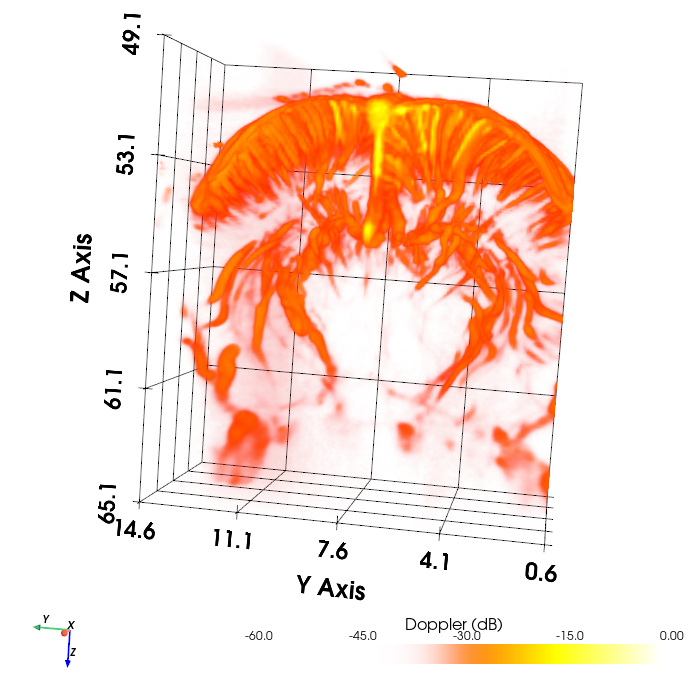

In [455]:
doppler3D_lab = doppler3D_voxels.copy()  #
doppler3D_lab.transform(qform, inplace=True)  # Apply the transformation to the image data

plotter_doppler = add_doppler_vol(doppler3D_lab, notebook=True, window_size=[700, 700], cmap="hot", opacity="sigmoid_15", clim=[-60, 0])
plotter_doppler.camera.up = (0, 0, -1)
plotter_doppler.camera_position = [(49.47776887390028, 0.9044120124061548, 54.75981233561904),
 (6.413190186992877, 7.590454907713185, 59.16153863679397),
 (-0.08851129417945298, 0.08336274461188356, -0.9925806786420197)]
plotter_doppler.show(jupyter_backend='static', title="Doppler Volume")

# 4. bg_atlas -> bps_atlas

In [456]:
from brainglobe_atlasapi import BrainGlobeAtlas
import brainglobe_space as bg_space

atlas_name = "whs_sd_rat_39um"
bg_atlas = BrainGlobeAtlas(atlas_name, check_latest=False)

region_name = "root" 

# Get the PyVista mesh for the specified structure
pv_brain_mesh = get_pv_mesh_from_atlas(bg_atlas, region_name)

# Now we create the target space 
target_space = bg_space.AnatomicalSpace("lpi") # New resolution to change the units from um to mm
trans_matrix_to_bps = bg_atlas.space.transformation_matrix_to(target_space)
print(trans_matrix_to_bps)

Selected structure Root
[[ 0.000e+00  0.000e+00 -1.000e+00  5.120e+02]
 [-1.000e+00  0.000e+00  0.000e+00  1.024e+03]
 [ 0.000e+00 -1.000e+00  0.000e+00  5.120e+02]
 [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]]


In [457]:
whs_origin_voxel = np.array([244, 623, 248])
bregma_voxel = np.array([246, 653, 440])
lambda_voxel = np.array([244, 442, 434])

resolution_um = np.array(bg_atlas.metadata['resolution']) # Convert to mm
resolution_mm = resolution_um*1e-3  # Convert to mm

resolution2Voxel =  np.diag(np.concatenate((1/resolution_um, [1])))  # Add a 1 for homogeneous coordinates
set_whs_origin = np.eye(4)
set_whs_origin[:3, 3] = -whs_origin_voxel

bregma2lambda_um = np.linalg.norm((bregma_voxel - lambda_voxel) * resolution_um[0])
bregma2lambda_mm = np.linalg.norm((bregma_voxel - lambda_voxel) * resolution_mm)
normalize_bregma2sigma_mm =  np.diag(np.concatenate(([resolution_mm[0]/bregma2lambda_mm]*3, [1])))  # Add a 1 for homogeneous coordinates
normalize_bregma2sigma_um =  np.diag(np.concatenate(([1/bregma2lambda_um]*3, [1])))  # Add a 1 for homogeneous coordinates

bregma2lambda_mm = np.linalg.norm((bregma_voxel - lambda_voxel) * resolution_mm)
print("Bregma to Lambda distance in mm:", bregma2lambda_mm)

bg_atlas2bps_atlas =  normalize_bregma2sigma_mm @ set_whs_origin @ trans_matrix_to_bps @ resolution2Voxel #@  # 
print("bg2atlas:\n", bg_atlas2bps_atlas)

Bregma to Lambda distance in mm: 8.232695852513926
bg2atlas:
 [[ 0.00000000e+00  0.00000000e+00 -1.21466895e-04  1.26957198e+00]
 [-1.21466895e-04  0.00000000e+00  0.00000000e+00  1.89962077e+00]
 [ 0.00000000e+00 -1.21466895e-04  0.00000000e+00  1.25062315e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [458]:
BrainToLab = gps_file["BrainToLab"][()]
print("BrainToLab:\n", BrainToLab)
Brain2Lab = BrainToLab * 1e3 # Convert to mm
Lab2Brain = np.linalg.inv(Brain2Lab)

bg_atlas2Lab = invert_z @ Brain2Lab @ bg_atlas2bps_atlas

BrainToLab:
 [[-3.76735303e-05  8.79171079e-03 -1.07882876e-03  4.81839373e-03]
 [-8.85233911e-03  5.42178454e-19  3.09130494e-04  7.08612699e-03]
 [ 3.06826282e-04  1.07948635e-03  8.78635512e-03 -5.79131900e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [459]:

region1_name = "M1" 
region2_name = "S1-hl" 

# Get the PyVista mesh for the specified structure
pv_region1_mesh = get_pv_mesh_from_atlas(bg_atlas, region1_name)
pv_region2_mesh = get_pv_mesh_from_atlas(bg_atlas, region2_name)

Selected structure Primary motor area
Selected structure Primary somatosensory area, hindlimb representation


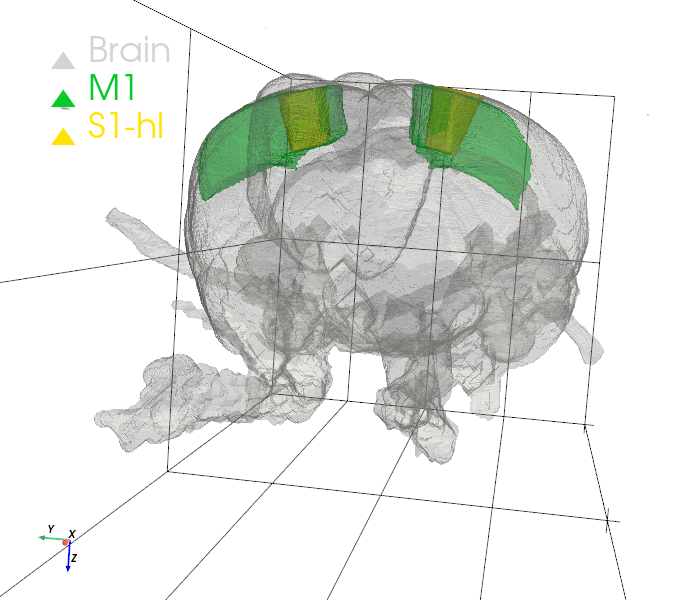

In [460]:
pv_brain_lab = pv_brain_mesh.copy()
pv_brain_lab .transform(bg_atlas2Lab, inplace=True)
pv_reg1_lab = pv_region1_mesh.copy()
pv_reg1_lab .transform(bg_atlas2Lab, inplace=True)
pv_reg2_lab = pv_region2_mesh.copy()
pv_reg2_lab .transform(bg_atlas2Lab, inplace=True)

plotter_brain = add_brain_mesh(pv_brain_lab,
                    window_size= [700, 600],
                    color="lightgray", 
                    label = "Brain",
                    opacity=0.2)
plotter_brain = add_brain_mesh(pv_reg1_lab,
                            plotter=plotter_brain,
                            color="permanentgreen", 
                            label = region1_name,
                            opacity=0.4)
plotter_brain = add_brain_mesh(pv_reg2_lab,
                            plotter=plotter_brain,
                            color="cadmiumlemon", 
                            label = region2_name,
                            opacity=0.6)
plotter_brain.show_axes()
plotter_brain.show_grid(
    bold =False, n_zlabels = 3, n_xlabels = 3
)
plotter_brain.add_legend(loc = 'upper left')             # show legend
plotter_brain.camera.up = (0, 0, -1)
plotter_brain.camera_position = [(49.47776887390028, 0.9044120124061548, 54.75981233561904),
 (6.413190186992877, 7.590454907713185, 59.16153863679397),
 (-0.08851129417945298, 0.08336274461188356, -0.9925806786420197)]
plotter_brain.show(jupyter_backend='static')#

# Doppler + atlas

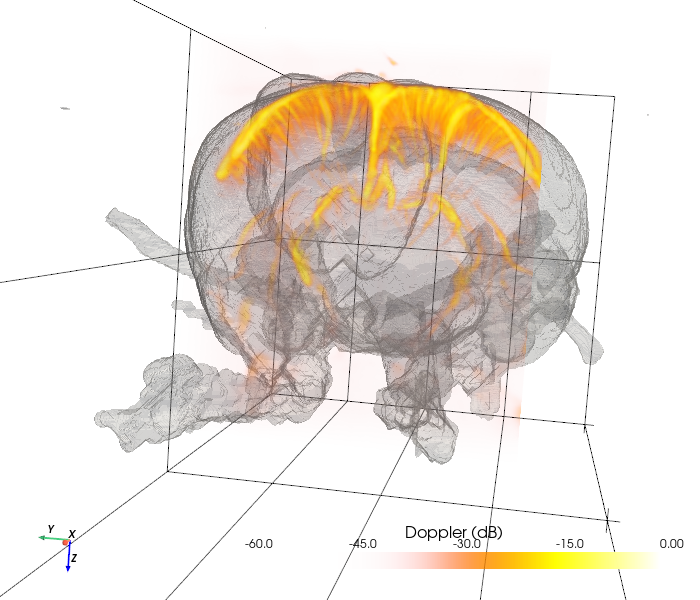

In [469]:


plotter_atlas_dopper = add_brain_mesh(pv_brain_lab,
                    window_size= [700, 600],
                    color="lightgray", 
                    label = "Brain",
                    opacity=0.2)

# plotter_atlas_dopper = add_brain_mesh(pv_reg1_lab,
#                             plotter=plotter_atlas_dopper,
#                             color="permanentgreen", 
#                             label = region1_name,
#                             opacity=0.4)
# plotter_atlas_dopper = add_brain_mesh(pv_reg2_lab,
#                             plotter=plotter_atlas_dopper,
#                             color="cadmiumlemon", 
#                             label = region2_name,
#                             opacity=0.6)

plotter_atlas_dopper = add_doppler_vol(doppler3D_lab,
                        plotter=plotter_atlas_dopper,
                        cmap="hot", 
                        opacity="sigmoid", 
                        opacity_unit_distance = 5,
                        clim=[-60, 0])

plotter_atlas_dopper.camera.up = (0, 0, -1)

plotter_atlas_dopper.show_axes()
plotter_atlas_dopper.show_grid(
    bold =False, n_zlabels = 3, n_xlabels = 3
)

plotter_atlas_dopper.camera_position = [(49.47776887390028, 0.9044120124061548, 54.75981233561904),
 (6.413190186992877, 7.590454907713185, 59.16153863679397),
 (-0.08851129417945298, 0.08336274461188356, -0.9925806786420197)]
plotter_atlas_dopper.show(jupyter_backend='static', title="Doppler Volume with Atlas Regions")

## Add transducer and 2D acquision

During the experiment we have 3 spaces: Brain, Lab, Probe. Once we manage to have our atlas in lab coordinates, we could simplify them to Lab and probe. The lab reference frame will move averything around the probe reference frame. Then its pov is static. We must then take our transducer, set . The probe space will have its origin center in the probe, and if we have done a good aproximation of the length and height, then its x,y coordinates should not move

In [462]:
# Create transducer with elevation focus
import pysonogen.transducers as Transducers
print(Transducers.available_transducers())

n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz


domino = Transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 10,
    frequency_Hz       = tx_freq*1e6,  # MHz),
)

print(domino)


['LinearArrayTransducer', 'MatrixArrayTransducer']
Transducer initialized in 0.0190 seconds.
LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=None, tx_N_active=128, F_over_D=None)


Focus: 1.150 mm, 0.000 mm, 8.200 mm


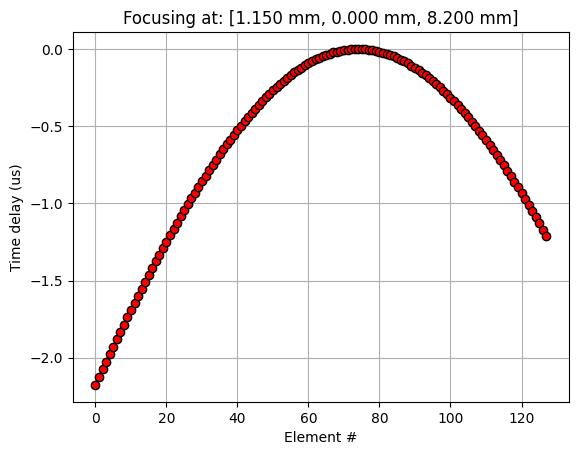

Focus: 1.150 mm, 0.000 mm, 8.200 mm


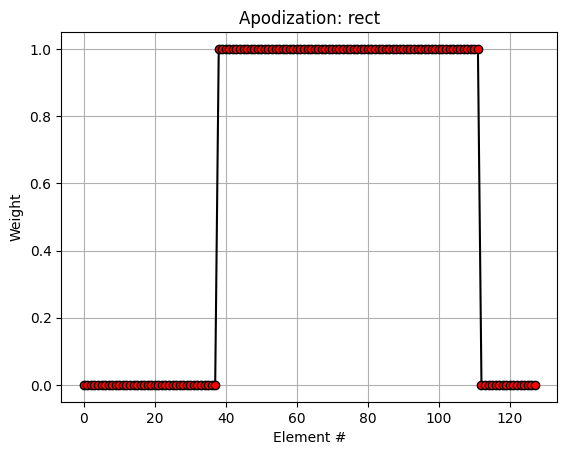

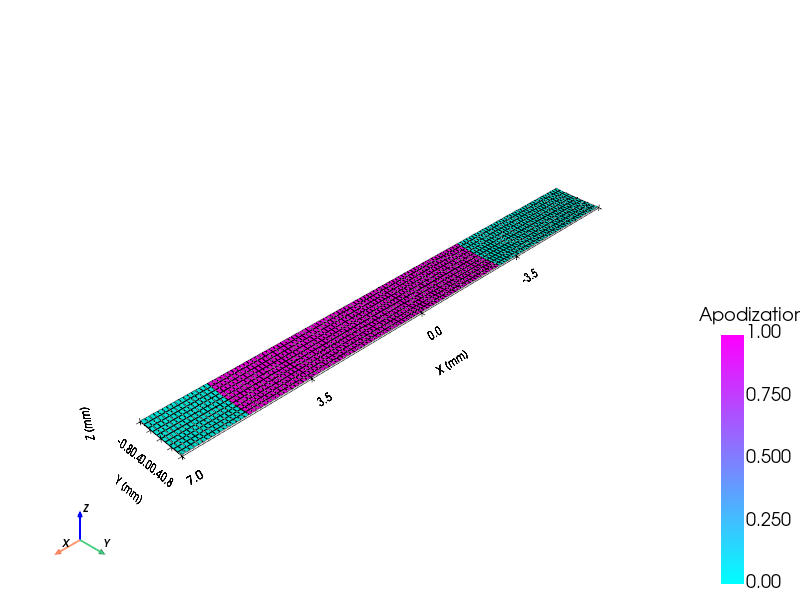

In [463]:
from pysonogen import pyfield

# Focalization spot
focus_mm =  np.array([1.15, 0, 8.2])  # mm [x, y, z]
delays = domino.compute_delays(focus_mm = focus_mm, plot = True)
apodization = domino.compute_apodization(focus_mm = focus_mm, F_over_D = 1, apodization_type='rect', plot = True)
domino.show(jupyter_backend='static')

In [464]:
TX_mesh = domino.get_mesh()

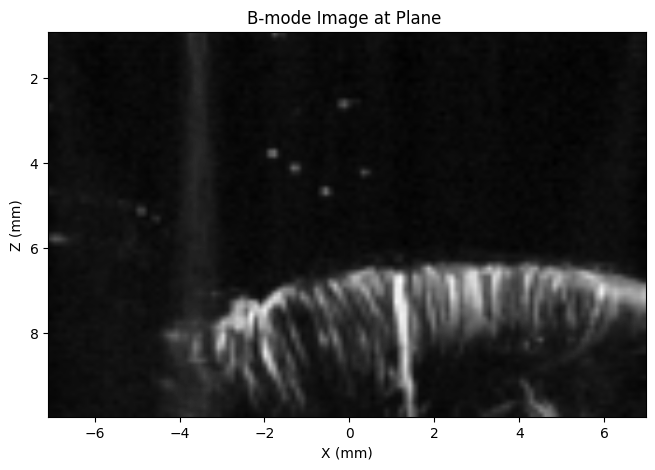

In [465]:
dx = scan2D_metadata['voxDim']['dx'][()]*1e3
dz = scan2D_metadata['voxDim']['dz'][()]*1e3

Bmode2D_dB = 20 * np.log10(np.abs(scan2D_processed.squeeze()) / np.max(np.abs(scan2D_processed.squeeze())))
Bmode2D_dB = np.clip(Bmode2D_dB, -60, 0)

extent=[voxelsToProbe2D[0,3]*1e3, voxelsToProbe2D[0,3]*1e3+Bmode2D_dB.shape[1]*dx,
                                                                        -voxelsToProbe2D[2,3]*1e3+ Bmode2D_dB.shape[0]*dz, -voxelsToProbe2D[2,3]*1e3]
n_y = 2
fig = plt.figure(figsize=(10, 5))
im = plt.imshow(Bmode2D_dB.squeeze(), aspect='equal', cmap='gray',extent=extent, interpolation='bilinear')
plt.title('B-mode Image at Plane ')
plt.xlabel('X (mm)')
plt.ylabel('Z (mm)')

plt.show()

In [466]:
doppler2D_lab = compute_2D_image_mesh(Bmode2D_dB, qform2D)


In [467]:
pv_brain_trans = pv_brain_lab.copy()
pv_brain_trans.transform(lab2transducer3D, inplace=True)

pv_reg1_trans = pv_reg1_lab.copy()
pv_reg1_trans.transform(lab2transducer3D, inplace=True)

pv_reg2_trans = pv_reg2_lab.copy()
pv_reg2_trans.transform(lab2transducer3D, inplace=True)

doppler3D_trans = doppler3D_lab.copy()
doppler3D_trans.transform(lab2transducer3D, inplace=True)

doppler2D_trans = doppler2D_lab.copy()
doppler2D_trans.transform(lab2transducer2D, inplace=True)


StructuredGrid (0x17c216a9c60)
  N Cells:      11557
  N Points:     11776
  X Bounds:     -7.095e+00, 6.875e+00
  Y Bounds:     -4.000e-01, -4.000e-01
  Z Bounds:     9.014e-01, 9.870e+00
  Dimensions:   92, 128, 1
  N Arrays:     1

In [470]:
final_plotter = add_brain_mesh(pv_brain_trans,
                    window_size= [1080, 960],
                    notebook=True,
                    color="lightgray", 
                    label = "Brain",
                    opacity=0.2)

final_plotter = add_brain_mesh(pv_reg1_trans,
                            plotter=final_plotter,
                            color="permanentgreen", 
                            label = region1_name,
                            opacity=0.2)

final_plotter = add_brain_mesh(pv_reg2_trans,
                            plotter=final_plotter,
                            color="blue", 
                            label = region2_name,
                            opacity=0.3)

# final_plotter = add_doppler_vol(doppler3D_trans,
#                         plotter=final_plotter,
#                         cmap="hot", 
#                         opacity="sigmoid_20", 
#                         opacity_unit_distance = 15,
#                         clim=[-60, 0])

final_plotter = add_transducer_mesh(TX_mesh,
                        plotter=final_plotter, show_edges=False)

final_plotter = add_2D_image(doppler2D_trans, plotter=final_plotter, cmap='gray', opacity=1.0, show_scalar_bar=True)

final_plotter.camera.up = (0, 0, -1)
final_plotter.show_axes()
final_plotter.show_grid(
    bold =False, n_zlabels = 3, n_xlabels = 3
)

final_plotter.add_legend(loc = 'upper left')             # show legend
final_plotter.show() # ,

Widget(value='<iframe src="http://localhost:60053/index.html?ui=P_0x179479e7ec0_103&reconnect=auto" class="pyv…

In [ ]:
final_plotter.camera_position = [(55.80139405597522, -23.687754759782813, -15.532937093081168),
 (2.267804888335531, 9.050676850801407, 13.923436841645591),
 (-0.43433198466736334, 0.09565318678951507, -0.8956596423597075)]

# Compute Pressure Field

In [109]:
Domino_field = pyfield.PyField(domino)
field_info_mm = {
    "x_extent" : [-0.25+focus_mm[0], 0.25+focus_mm[0]],
    "y_extent" : [-0.5+focus_mm[1], 0.5+focus_mm[1]],
    "z_extent" : [-1+focus_mm[2], 1+focus_mm[2]],
    "dx" : 0.0125,
    "dy" : 0.025,
    "dz" : 0.05,
}
print("Field info:", field_info_mm)
pressure_field, x, y, z = Domino_field.compute_pressure_field(field_info_mm)

Successfully initialized PyField with 
 LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=rect, tx_N_active=74, F_over_D=1)
Field info: {'x_extent': [np.float64(0.8999999999999999), np.float64(1.4)], 'y_extent': [np.float64(-0.5), np.float64(0.5)], 'z_extent': [np.float64(7.199999999999999), np.float64(9.2)], 'dx': 0.0125, 'dy': 0.025, 'dz': 0.05}
Creating simulation grid...
Computing spatial impulse response...
Computing SIR for 68921 points and 1280 patches...
Computing all patch events...
Accumulating SIR from events...
Total computation time: 15.3680 seconds.
Computing pressure field...
Original h shape: (512, 68921)
Reshaped h shape: (512, 41, 41, 41)
Performing FFT...
Frequency searched: 12500000.0 Hz. Found: 12328767.123287672 Hz


Taking slice x_ind, y_ind, z_ind = 21/41, 21/41, 21/41


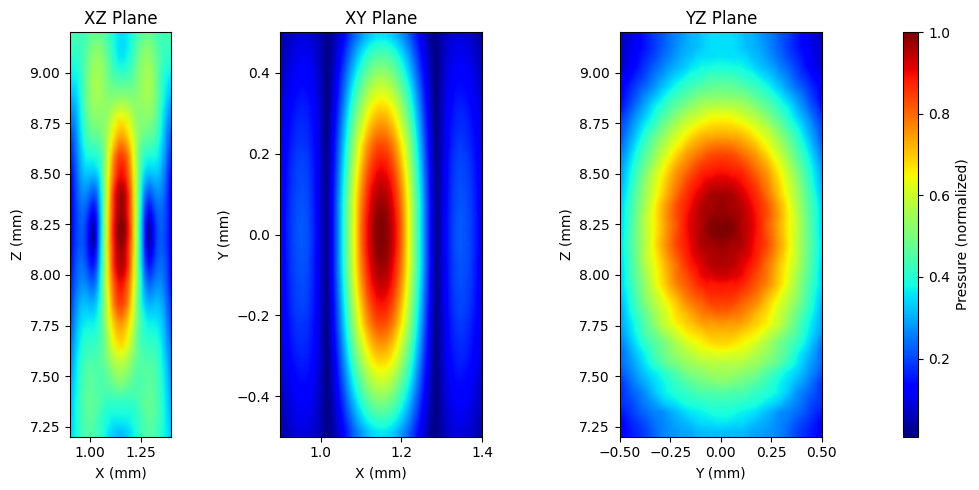

In [110]:
import pysonogen
pysonogen.plot_field_planes(pressure_field,
                               x, y, z, figsize = (10, 5), interpolation="bilinear")

pressure_plotter, pressure_vol_mesh = pysonogen.plot_pressure_field(pressure_field,
                               x, y, z, notebook = True, return_mesh = True, window_size = [620, 780])

pressure_plotter.show(jupyter_backend='static')  # Add this parameter

# 5. Plot brain and pressure field

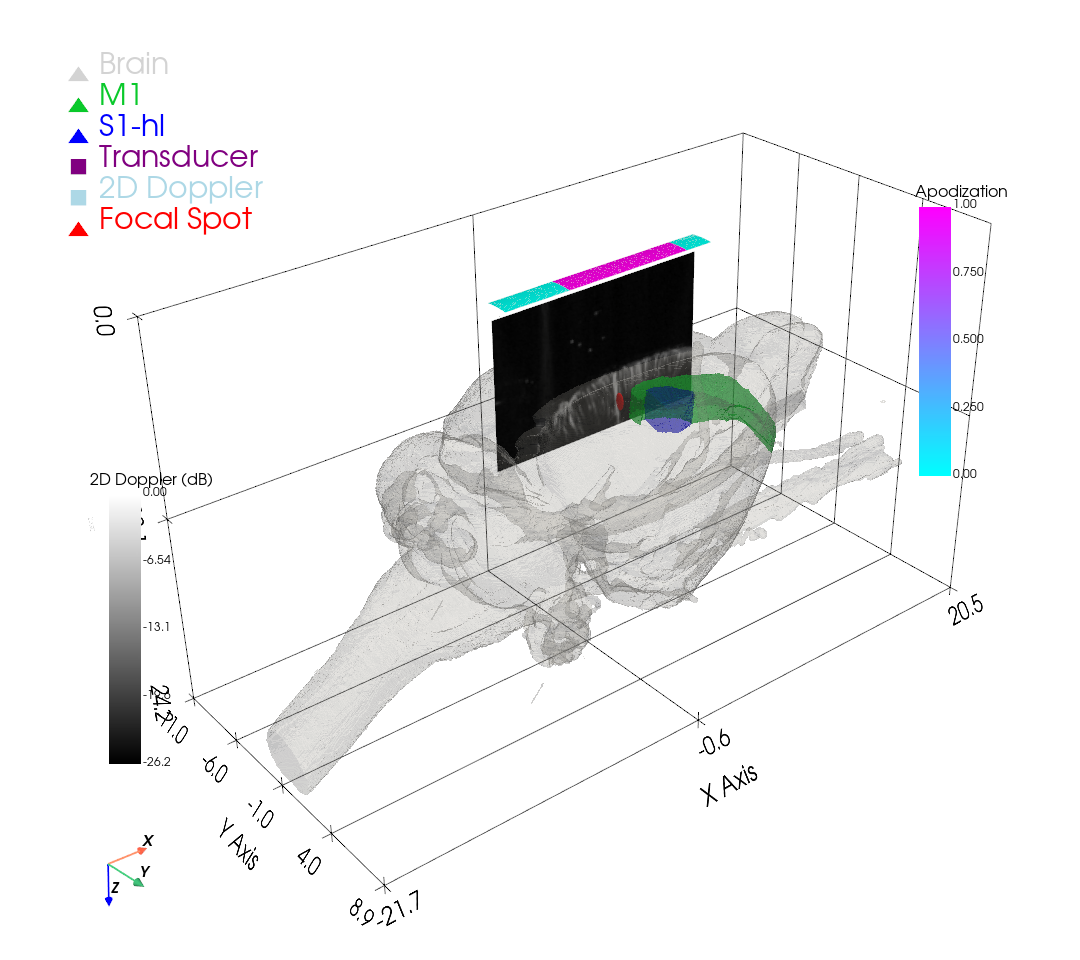

In [479]:
final_plotter = add_brain_mesh(pv_brain_trans,
                    window_size= [1080, 960],
                    notebook=True,
                    color="lightgray", 
                    label = "Brain",
                    opacity=0.2)

final_plotter = add_brain_mesh(pv_reg1_trans,
                            plotter=final_plotter,
                            color="permanentgreen", 
                            label = region1_name,
                            opacity=0.5)

final_plotter = add_brain_mesh(pv_reg2_trans,
                            plotter=final_plotter,
                            color="blue", 
                            label = region2_name,
                            opacity=0.4)

# final_plotter = add_doppler_vol(doppler3D_trans,
#                         plotter=final_plotter,
#                         cmap="hot", 
#                         opacity="sigmoid_20", 
#                         opacity_unit_distance = 15,
#                         clim=[-60, 0])

final_plotter = add_transducer_mesh(TX_mesh,
                        plotter=final_plotter, show_edges=False)

final_plotter = add_2D_image(doppler2D_trans, plotter=final_plotter, cmap='gray', opacity=1.0, show_scalar_bar=True)

final_plotter = add_pressure_vol(pressure_vol_mesh,
                        plotter=final_plotter,
                        plot_focal_spot=True)

final_plotter.camera.up = (0, 0, -1)

final_plotter.show_axes()
final_plotter.show_grid(
    bold =False, n_zlabels = 3, n_xlabels = 3
)
final_plotter.camera_position = [(-55.65343136721747, 67.68050573124735, -38.15535103914566),
 (-2.7639250557894544, -2.3520870333609127, 12.82291379311279),
 (0.32235412888499854, -0.38579591954579057, -0.8644358414900504)]
final_plotter.add_legend(loc = 'upper left')             # show legend
final_plotter.show(jupyter_backend='static') # ,

In [477]:
final_plotter.camera_position

[(-55.65343136721747, 67.68050573124735, -38.15535103914566),
 (-2.7639250557894544, -2.3520870333609127, 12.82291379311279),
 (0.32235412888499854, -0.38579591954579057, -0.8644358414900504)]

In [ ]:
make_movie = False

if make_movie:

    video_plotter = add_brain_mesh(pv_brain_probe,
                    window_size= [1080, 960],
                    notebook=True,
                    off_screen=True,
                    color="lightgray", 
                    label = "Brain",
                    opacity=0.2)

    video_plotter = add_doppler_vol(doppler3D_probe,
                            plotter=video_plotter,
                            cmap="hot", 
                            opacity="sigmoid", 
                            opacity_unit_distance = 5,
                            clim=[-60, 0])


    video_plotter = add_brain_mesh(pv_reg1_probe,
                                plotter=video_plotter,
                                color="permanentgreen", 
                                label = region1_name,
                                opacity=0.4)

    video_plotter = add_brain_mesh(pv_reg2_probe,
                                plotter=video_plotter,
                                color="blue", 
                                label = region2_name,
                                opacity=0.6)

    video_plotter = add_transducer_mesh(TX_mesh,
                            plotter=video_plotter, show_edges=False)

    video_plotter = add_pressure_vol(pressure_vol_mesh,
                            plotter=video_plotter,
                            plot_focal_spot=True)

    video_plotter.camera.up = (0, 0, -1)
    video_plotter.camera_position = [(67.95392466413932, -0.6249611748695701, -13.191532202673908),
    (3.8237745557155436, -1.4869571558041679, 13.112628093230912),
    (-0.37954974503079236, 0.0060970103961559925, -0.9251512403446744)]
    video_plotter.show_axes()
    video_plotter.show_grid(
        bold =False, n_zlabels = 3, n_xlabels = 3
    )

    video_plotter.add_legend(loc = 'upper left')             # show legend


    # Render once before movie to apply camera and settings
    video_plotter.render()

    # Open movie file and define frame settings
    n_frames = 180
    video_filename = "sonogen_experiment.mp4"
    video_plotter.open_movie(video_filename, framerate=20)

    # Rotation loop
    video_plotter.show(auto_close=False)

    delta_angle_deg = 360 / n_frames
    angle_deg = 0 
    for i in range(n_frames):
        angle_deg += 2
        video_plotter.camera.azimuth = angle_deg # Rotate camera
        video_plotter.render()
        video_plotter.write_frame()

    # Finalize and save
    video_plotter.close()
    print(f" Video saved to: {video_filename}")